## Importing Required Libraries

In [37]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing(Training Image Preprocessing)

In [40]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 13090 files belonging to 15 classes.


## Data Augmentation

In [43]:
# Data Augmentation - milder settings
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# Apply augmentation to training set only
training_set = training_set.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)

## Validation Image Preprocessing

In [46]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 300 files belonging to 15 classes.


In [48]:
training_set

<_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 15), dtype=tf.float32, name=None))>

In [50]:
for x,y in training_set:
    print (x,x.shape)
    print (y,y.shape)
    break

tf.Tensor(
[[[[ 88.64049   75.18713   32.89244 ]
   [111.60742  100.11361   59.1793  ]
   [157.65445  150.46632  114.27282 ]
   ...
   [ 92.97808  121.97482   43.217632]
   [117.80084  145.27489   55.49253 ]
   [146.8938   171.69485   78.6501  ]]

  [[ 79.284424  67.402985  23.484661]
   [124.20711  115.74466   72.39671 ]
   [177.24623  174.00203  133.7152  ]
   ...
   [100.184555 128.24197   45.684177]
   [123.03865  149.0393    57.943577]
   [139.47964  162.93982   70.13478 ]]

  [[ 91.31938   81.96527   35.2382  ]
   [142.1264   137.22995   90.25619 ]
   [185.43448  186.15198  140.0369  ]
   ...
   [117.876884 145.42062   58.637726]
   [128.45987  153.4079    60.66243 ]
   [131.57031  153.75696   61.967354]]

  ...

  [[183.15634  164.78394  143.84277 ]
   [206.9133   190.85394  168.52335 ]
   [213.46545  198.37296  173.16747 ]
   ...
   [ 81.80203   99.78213   35.74987 ]
   [ 83.63238  103.53253   36.918427]
   [ 85.37518  106.9476    34.981075]]

  [[172.83118  157.85237  137.9829

## Building Model

In [53]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [55]:
model = Sequential()

## Building Convolution Layer

In [58]:
model.add(tf.keras.layers.Rescaling(1./255, input_shape=(128, 128, 3)))

model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [60]:
model.add(Conv2D(filters=64,kernel_size=3,padding="same",activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [62]:
model.add(Conv2D(filters=128,kernel_size=3,padding="same",activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [64]:
model.add(Conv2D(filters=256,kernel_size=3,padding="same",activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

## Flattening Operation (Its Done to feed data to the neural network)

In [67]:
model.add(tf.keras.layers.Dropout(0.25)) #To Avoid Overfitting


In [69]:
model.add(Flatten())

In [71]:
 model.add(Dense(units=1024,activation="relu"))

In [73]:
model.add(tf.keras.layers.Dropout(0.5)) #To avoid overfitting


In [75]:
#Output Layer
model.add(Dense(units=15,activation="softmax"))

## Compiling Model

In [78]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [80]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     9,438,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │        15,375 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,625,839 (40.53 MB)

 Trainable params: 10,625,839 (40.53 MB)

 Non-trainable params: 0 (0.00 B)

 ## Model Training

In [91]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)


Epoch 1/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 945s 2s/step - accuracy: 0.8498 - loss: 0.4258 - val_accuracy: 0.8633 - val_loss: 2.0579
Epoch 2/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 1024s 2s/step - accuracy: 0.8550 - loss: 0.4162 - val_accuracy: 0.8133 - val_loss: 2.0967
Epoch 3/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 1016s 2s/step - accuracy: 0.8592 - loss: 0.4111 - val_accuracy: 0.7200 - val_loss: 2.2183
Epoch 4/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 1083s 3s/step - accuracy: 0.8633 - loss: 0.3913 - val_accuracy: 0.7633 - val_loss: 2.3840
Epoch 5/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 1559s 4s/step - accuracy: 0.8665 - loss: 0.3817 - val_accuracy: 0.7900 - val_loss: 2.2820
Epoch 6/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 1571s 4s/step - accuracy: 0.8691 - loss: 0.3754 - val_accuracy: 0.8467 - val_loss: 2.1553
Epoch 7/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 1225s 3s/step - accuracy: 0.8694 - loss: 0.3722 - val_accuracy: 0.8633 - val_loss: 1.9911
Epoch 8/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 974s 2s/step - accuracy: 0.8759 - loss: 0.3527 - va

## Model Evaluation

In [94]:
# Model Evaluation on Training Set
train_loss,train_acc=model.evaluate(training_set)


410/410 ━━━━━━━━━━━━━━━━━━━━ 476s 1s/step - accuracy: 0.9332 - loss: 0.1996


In [96]:
print('Training accuracy:', train_acc)

Training accuracy: 0.9332314729690552


In [98]:
# Model Evaluation On Validation Set
val_loss,val_acc=model.evaluate(validation_set)


10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 623ms/step - accuracy: 0.8133 - loss: 2.0856


In [100]:
print(val_loss,val_acc)

2.0856029987335205 0.8133333325386047


## Saving Model

In [107]:
model.save("trained_model_10m.keras")

import json
class_name = validation_set.class_names
with open('class_names.json', 'w') as f:
    json.dump(class_name, f)
print("Class names saved!")

Class names saved!


In [109]:
training_history.history #Return Dictionary of history


{'accuracy': [0.8498089909553528,
  0.855003833770752,
  0.8592054843902588,
  0.8633307814598083,
  0.8665393590927124,
  0.8691367506980896,
  0.869442343711853,
  0.8758594393730164,
  0.8768525719642639,
  0.8799083232879639],
 'loss': [0.42584213614463806,
  0.4161531627178192,
  0.41108208894729614,
  0.3912770450115204,
  0.38166454434394836,
  0.37542685866355896,
  0.37217819690704346,
  0.3526625335216522,
  0.34849897027015686,
  0.33788034319877625],
 'val_accuracy': [0.8633333444595337,
  0.8133333325386047,
  0.7200000286102295,
  0.7633333206176758,
  0.7900000214576721,
  0.846666693687439,
  0.8633333444595337,
  0.8399999737739563,
  0.8600000143051147,
  0.8133333325386047],
 'val_loss': [2.057870626449585,
  2.0966804027557373,
  2.2182726860046387,
  2.3840270042419434,
  2.281980037689209,
  2.155254364013672,
  1.9911389350891113,
  1.9341548681259155,
  1.953386664390564,
  2.0856029987335205]}

In [111]:
#Recording History in json
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

In [113]:
print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## Accuracy Visualization

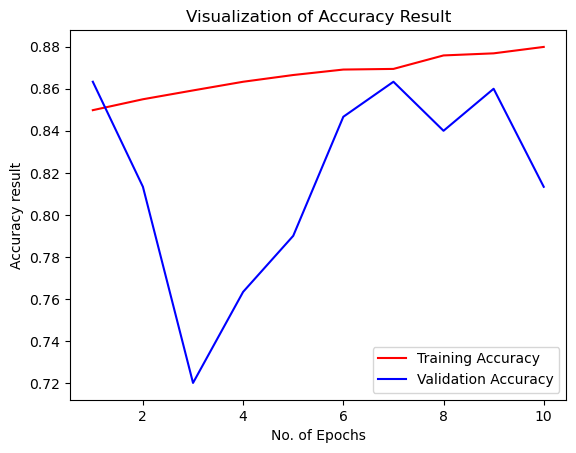

In [116]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.ylabel('Accuracy result')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

## Some Other Metrics For Model Evaluation

In [119]:
class_name = validation_set.class_names
class_name

['aphid_valid',
 'black_rust_valid',
 'blast_test_valid',
 'brown_rust_valid',
 'common_root_rot_valid',
 'fusarium_head_blight_valid',
 'healthy_valid',
 'leaf_blight_valid',
 'mildew_valid',
 'mite_valid',
 'septoria_valid',
 'smut_valid',
 'stem_fly_valid',
 'tan_spot_valid',
 'yellow_rust_valid']

In [121]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 300 files belonging to 15 classes.


In [123]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

300/300 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step


(array([[6.73248649e-01, 1.06615124e-04, 6.48162995e-07, ...,
         1.15464745e-05, 3.61947641e-02, 8.77448031e-07],
        [2.03127176e-01, 2.38329824e-03, 3.73215795e-01, ...,
         1.41194105e-05, 2.67717153e-01, 4.95704580e-06],
        [7.12792218e-01, 1.24750973e-03, 1.63823906e-02, ...,
         8.28144373e-04, 2.08831072e-01, 2.02224783e-06],
        ...,
        [1.40783771e-14, 1.86144988e-10, 4.09460524e-18, ...,
         7.58759945e-24, 2.64312044e-11, 1.00000000e+00],
        [1.77347648e-08, 9.60887481e-11, 1.14912290e-12, ...,
         1.40718693e-14, 4.58170252e-05, 9.99886751e-01],
        [9.85006343e-18, 2.35583230e-18, 2.17308546e-26, ...,
         1.48794199e-27, 2.35954759e-17, 1.00000000e+00]], dtype=float32),
 (300, 15))

In [125]:
predicted_categories = tf.argmax(y_pred, axis=1)
predicted_categories 

<tf.Tensor: shape=(300,), dtype=int64, numpy=
array([ 0,  2,  0,  0,  0,  0, 11,  0,  0,  4,  0,  0,  0,  0,  4,  0,  0,
        0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2, 12,  2, 11,  2,  0,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  8,  3, 14,  3,  3,  3,
        3,  3,  3,  6,  3,  3,  3,  3,  3,  3,  3,  3, 11,  4,  4,  6,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  1,  4,  4,  4,  4,  5,  5,
        5,  5,  5,  5,  9,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,
       11,  2, 14, 14, 14, 14, 14, 14,  6, 14, 14, 14, 14, 14, 14, 13, 14,
       14, 14, 14,  6,  7,  7,  7,  7,  7,  7,  3, 14,  7,  4,  7,  7,  7,
        7,  7,  1,  7, 13,  7,  7,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  7,  8,  8,  6,  8,  8,  0,  9,  9, 13,  9, 13,  9,
        9,  9,  9,  9,  9,  4,  9, 14,  9,  9,  9,  9,  7, 10, 10, 10, 10,
       10,  8, 10, 10, 10, 10, 10,  7, 10, 10,  1, 10,

In [127]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
true_categories

<tf.Tensor: shape=(300, 15), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [129]:
Y_true = tf.argmax(true_categories, axis=1)
Y_true

<tf.Tensor: shape=(300,), dtype=int64, numpy=
array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,
        5,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,
        7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,
        9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,

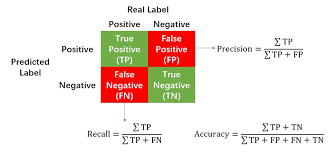!

In [132]:
from sklearn.metrics import classification_report, confusion_matrix

In [134]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                            precision    recall  f1-score   support

               aphid_valid       0.89      0.80      0.84        20
          black_rust_valid       0.87      1.00      0.93        20
          blast_test_valid       0.89      0.85      0.87        20
          brown_rust_valid       0.89      0.85      0.87        20
     common_root_rot_valid       0.81      0.85      0.83        20
fusarium_head_blight_valid       0.90      0.90      0.90        20
             healthy_valid       0.25      0.10      0.14        20
         leaf_blight_valid       0.79      0.75      0.77        20
              mildew_valid       0.90      0.90      0.90        20
                mite_valid       0.93      0.70      0.80        20
            septoria_valid       1.00      0.80      0.89        20
                smut_valid       0.83      1.00      0.91        20
            stem_fly_valid       0.95      1.00      0.98        20
            tan_spot_valid       0.78      0.70

In [136]:
cm = confusion_matrix(Y_true,predicted_categories)
cm


array([[16,  0,  1,  0,  2,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0],
       [ 0, 20,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0, 17,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  0,  0],
       [ 0,  0,  0, 17,  0,  0,  1,  0,  1,  0,  0,  0,  0,  0,  1],
       [ 0,  1,  0,  0, 17,  0,  1,  0,  0,  0,  0,  1,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 18,  0,  0,  0,  1,  0,  1,  0,  0,  0],
       [ 0,  0,  1,  0,  0,  0,  2,  0,  0,  0,  0,  0,  0,  1, 16],
       [ 0,  1,  0,  1,  1,  0,  0, 15,  0,  0,  0,  0,  0,  1,  1],
       [ 0,  0,  0,  0,  0,  0,  1,  1, 18,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  1,  0,  0,  1,  0, 14,  0,  0,  0,  2,  1],
       [ 0,  1,  0,  0,  0,  0,  1,  1,  1,  0, 16,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 20,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 20,  0,  0],
       [ 0,  0,  0,  1,  0,  2,  2,  1,  0,  0,  0,  0,  0, 14,  0],
       [ 0,  0,  0,  0,  0,  0,  0

## Confusion Matrix Visualization

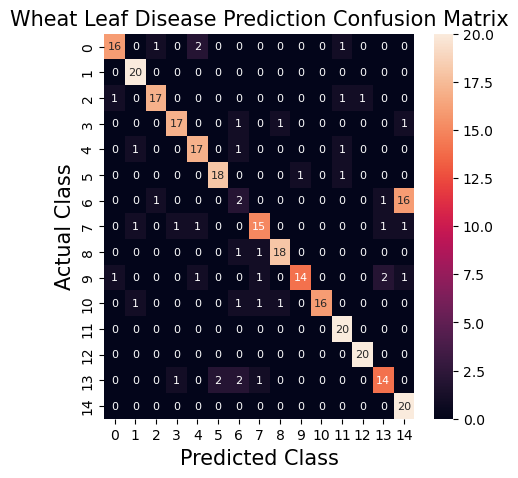

In [149]:
plt.figure(figsize=(5, 5))
sns.heatmap(cm,annot=True,annot_kws={"size": 8})

plt.xlabel('Predicted Class',fontsize = 15)
plt.ylabel('Actual Class',fontsize = 15)
plt.title('Wheat Leaf Disease Prediction Confusion Matrix',fontsize = 15)
plt.show()